# Channel x Trial Beta Type 稳定性分析

本 Notebook 用于判断同一个通道在 block 内每个有效 trial 的 beta 动态模式是否在 Type 1 与 Type 2 之间变化。

- Type 1：speech onset 下降，言语持续过程中回升，offset 附近再次下降，言语间隙恢复。
- Type 2：speech onset 下降，言语持续过程中维持低功率，offset 后言语间隙恢复。

## 1. 初始化

In [14]:
from __future__ import annotations

import os
import sys
from pathlib import Path

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name == "channelXtrial":
    PROJECT_DIR = PROJECT_DIR.parent
if not (PROJECT_DIR / "audio_cross_3band_utils.py").is_file():
    PROJECT_DIR = Path(r"E:\ECoG\Codex任务一\code\9.29test")

os.environ.setdefault("_MNE_FAKE_HOME_DIR", str(PROJECT_DIR / ".mne-home"))
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_DIR / ".mplconfig"))
(PROJECT_DIR / ".mne-home").mkdir(exist_ok=True)
(PROJECT_DIR / ".mplconfig").mkdir(exist_ok=True)

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

for module_name in tuple(sys.modules):
    if module_name == "channelXtrial" or module_name.startswith("channelXtrial."):
        sys.modules.pop(module_name, None)

%matplotlib inline

import pandas as pd

from channelXtrial import run_channelxtrial_analysis

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)

print(f"项目目录: {PROJECT_DIR}")

项目目录: e:\ECoG\Codex任务一\code\9.29test


## 2. 参数区

In [15]:
WORKSPACE_ROOT = PROJECT_DIR.parent.parent
SUBJECT_ID = "HS001"
DATA_DIR = WORKSPACE_ROOT / "data" / SUBJECT_ID / "standardized"

FIF_PATH = DATA_DIR / "ECoG" / "ecog_TEST_clean_car-raw.fif"
EVENT_SOURCE = DATA_DIR / "events" / "onset.npy"
OFFSET_SOURCE = DATA_DIR / "events" / "offset.npy"
WAV_PATH = DATA_DIR / "audio" / "analog1.wav"

OUTPUT_DIR = PROJECT_DIR / "outputs" / SUBJECT_ID / "channelXtrial"

PICKS = "data"
PROGRESS_POINTS = 101
DURATION_MAD_THRESHOLD = 2.5
MIN_TRIALS_AFTER_FILTER = 3
PRE_POST_WINDOW_SECONDS = None

# None 表示自动选择最可能发生切换或不确定的通道作为示例。
# 可写 None、完整通道名如 "ECoG_124"，或数字编号如 124。
EXAMPLE_CHANNEL = 124

# None 表示显示该通道全部有效 trial；也可以设成 24、36 等数字。
MAX_DISPLAY_TRIALS = None

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"输出目录: {OUTPUT_DIR}")

输出目录: e:\ECoG\Codex任务一\code\9.29test\outputs\HS001\channelXtrial


## 3. 运行 Channel x Trial 分析

这一格会重新构建 beta-only 有效 trial epoch，然后对每个 `channel × trial` 判定 Type 1、Type 2 或 Uncertain。

Reading 0 ... 116400  =      0.000 ...   291.000 secs...
有效 trial 数: 44
channel x trial 行数: 5544
通道数: 126
示例通道: ECoG_124
pre/post 窗口: 1.366 s


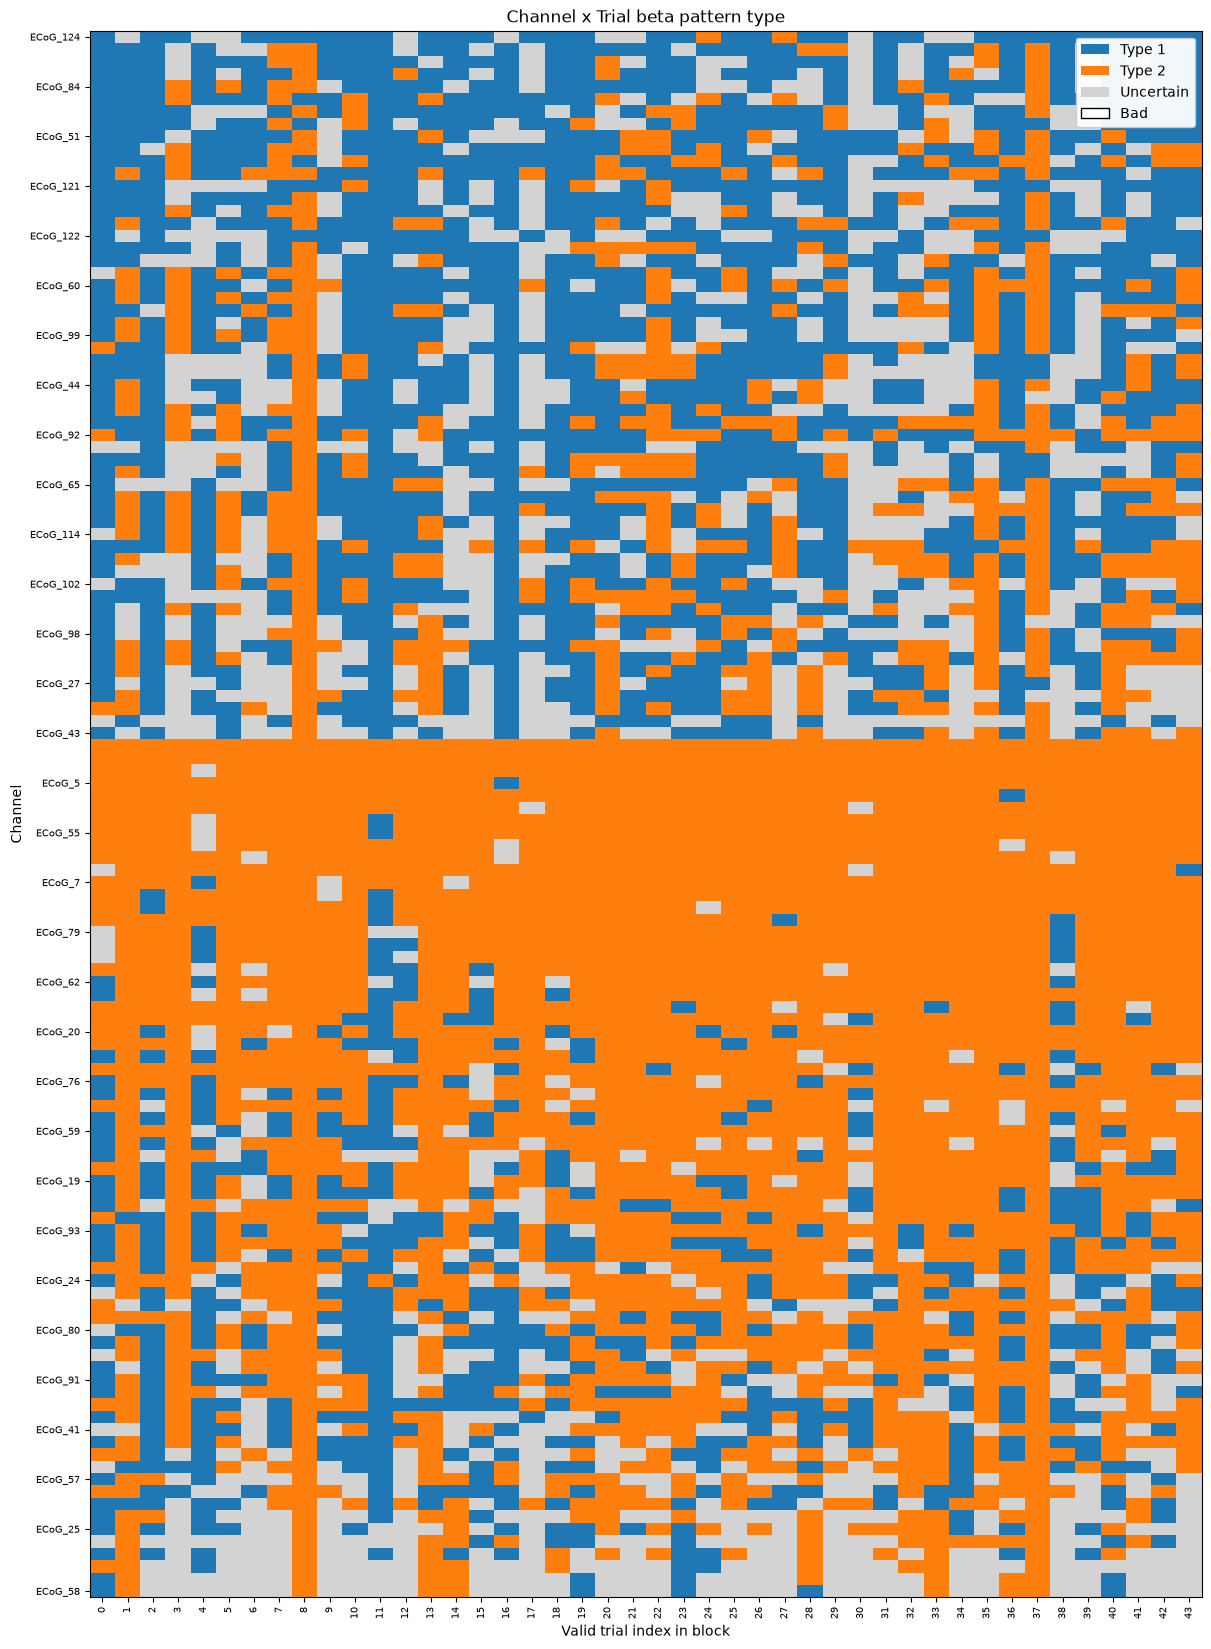

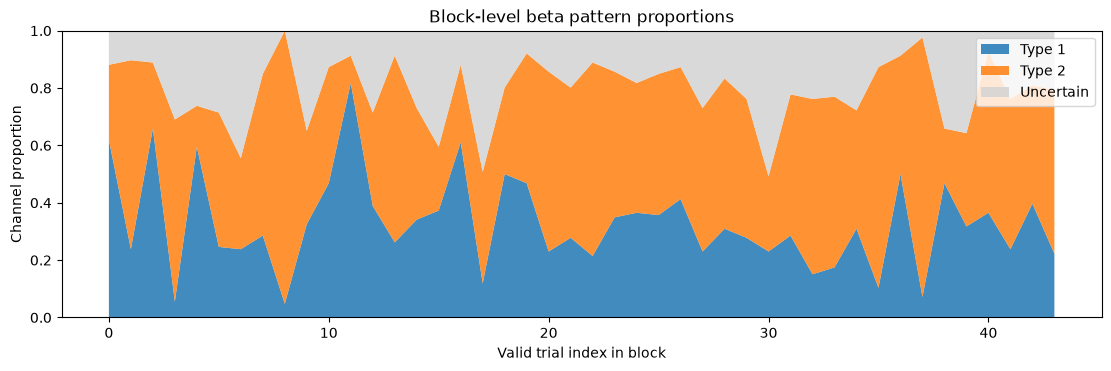

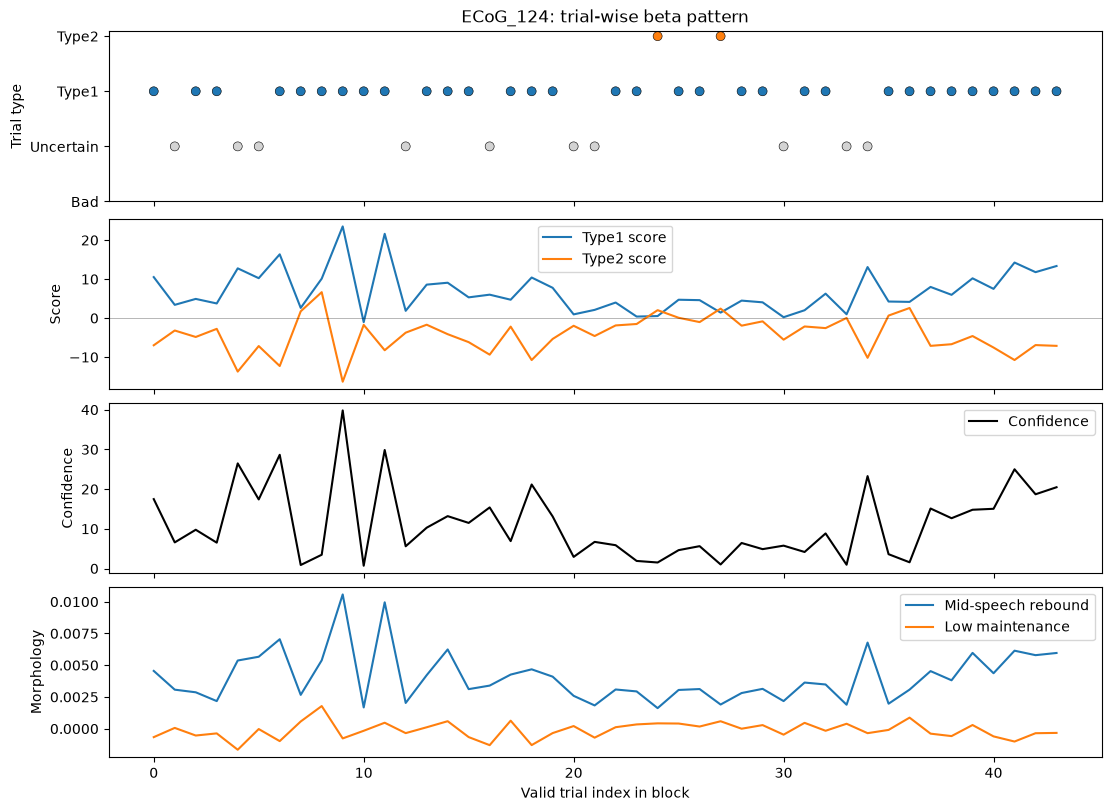

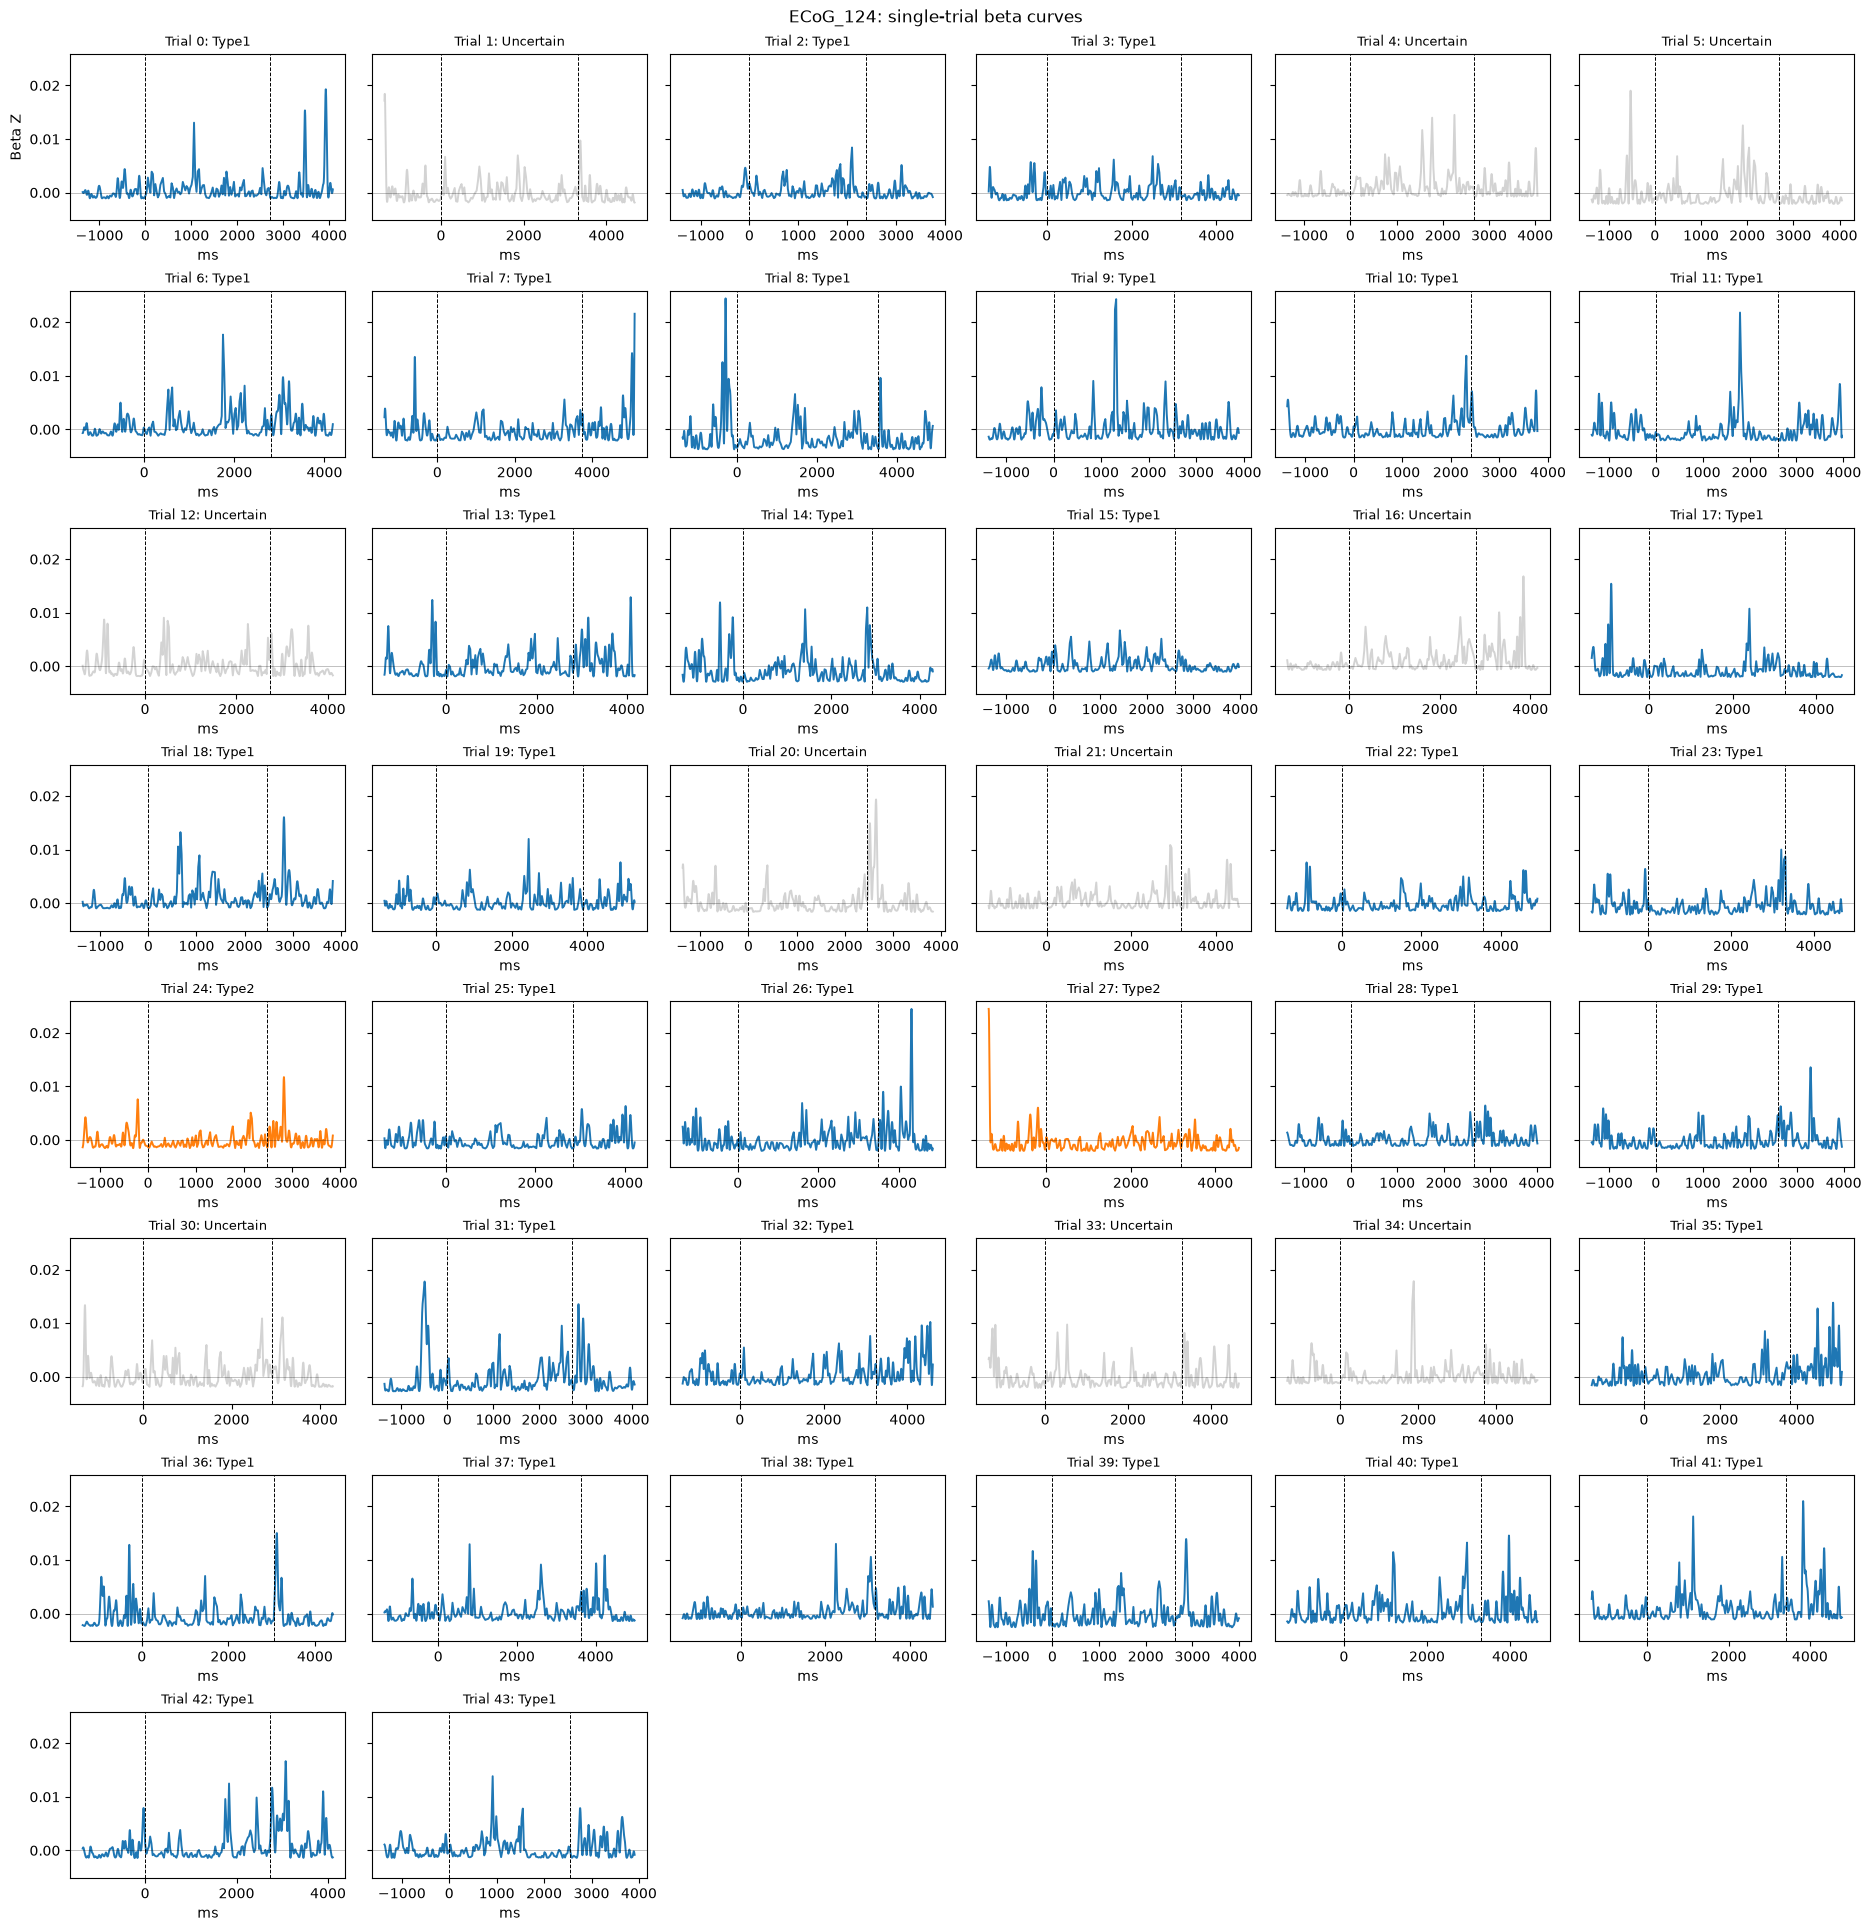

In [16]:
result = run_channelxtrial_analysis(
    fif_path=FIF_PATH,
    event_source=EVENT_SOURCE,
    offset_source=OFFSET_SOURCE,
    wav_path=WAV_PATH,
    output_dir=OUTPUT_DIR,
    picks=PICKS,
    progress_points=PROGRESS_POINTS,
    duration_mad_threshold=DURATION_MAD_THRESHOLD,
    min_trials_after_filter=MIN_TRIALS_AFTER_FILTER,
    pre_post_window=PRE_POST_WINDOW_SECONDS,
    example_channel=EXAMPLE_CHANNEL,
    max_display_trials=MAX_DISPLAY_TRIALS,
)

print(f"有效 trial 数: {len(result.beta_epochs.events)}")
print(f"channel x trial 行数: {len(result.classified_trials)}")
print(f"通道数: {result.channel_stability.shape[0]}")
print(f"示例通道: {result.example_channel}")
print(f"pre/post 窗口: {result.beta_epochs.pre_post_window:.3f} s")

## 4. 查看结果表

In [ ]:
display(result.channel_stability.head(20))
display(result.classified_trials.head(20))

## 5. 输出文件

In [ ]:
pd.DataFrame({"file": sorted(path.name for path in OUTPUT_DIR.glob("*"))})